In [11]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import intake
from datetime import datetime
mpl.rcParams['figure.dpi'] = 72

In [12]:
def convert_time(time_array):
    """Convert cftime to standard datetime64"""
    if hasattr(time_array[0], 'year'):
        return np.array([np.datetime64(datetime(t.year, t.month, t.day, t.hour)) 
                         for t in time_array])
    return time_array

In [14]:
# catalog = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
catalog = "/global/homes/f/feng045/program/hackathon/catalog/NERSC/main.yaml"

# current_location = "online"
current_location = "NERSC"
source = "scream_ne120"
catalog_param = {
    "zoom": 8,
    # "time": "PT3H",
}

# Load data from catalog
# cat = intake.open_catalog(catalog)[current_location]
cat = intake.open_catalog(catalog)
ds = cat[source](**catalog_param).to_dask()
ds = ds.pipe(egh.attach_coords)
# Convert cftime to standard datetime
ds = ds.assign_coords(time=convert_time(ds.time.values))
ds

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 2TB
Dimensions:          (time: 3168, cell: 786432, level: 25)
Coordinates:
    lat              (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon              (cell) float64 6MB 45.0 45.18 44.82 ... 315.2 314.8 315.0
    lev              (level) int64 200B dask.array<chunksize=(4,), meta=np.ndarray>
    crs              int64 8B 0
  * cell             (cell) int64 6MB 0 1 2 3 4 ... 786428 786429 786430 786431
  * time             (time) datetime64[us] 25kB 2019-08-01T03:00:00 ... 2020-...
Dimensions without coordinates: level
Data variables: (12/39)
    clt              (time, cell) float32 10GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    hflsd            (time, cell) float32 10GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    hfssd            (time, cell) float32 10GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    huss             (time, cell) float32 10GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    lwcre            (time, cell) float32 10GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    pr               (time, cell) float32 10GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    ...               ...
    omega            (time, level, cell) float32 249GB dask.array<chunksize=(24, 4, 65536), meta=np.ndarray>
    qall             (time, level, cell) float32 249GB dask.array<chunksize=(24, 4, 65536), meta=np.ndarray>
    ta               (time, level, cell) float32 249GB dask.array<chunksize=(24, 4, 65536), meta=np.ndarray>
    ua               (time, level, cell) float32 249GB dask.array<chunksize=(24, 4, 65536), meta=np.ndarray>
    va               (time, level, cell) float32 249GB dask.array<chunksize=(24, 4, 65536), meta=np.ndarray>
    zg               (time, level, cell) float32 249GB dask.array<chunksize=(24, 4, 65536), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          3
    averaging_frequency_units:    nhours
    averaging_type:               AVERAGE
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [15]:
# # Read from calculated data
# zarr_file = "/pscratch/sd/w/wcmca1/hackathon/healpix/scream/scream_pr6h_z8.zarr"

# ds = xr.open_zarr(zarr_file)
# ds

In [16]:
# Scaling factor to convert pr to [mm/h]
pr_scale = 3600000.

ds.pr.attrs

{'averaging_count_tracker': 'avg_count_Scalar2D_ncol',
 'long_name': 'precip_liq_surf_mass_flux',
 'units': 'm s^-1'}

In [17]:
ds.time[0:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2019-08-01T03:00:00.000000', '2019-08-01T06:00:00.000000',
       '2019-08-01T09:00:00.000000', '2019-08-01T12:00:00.000000',
       '2019-08-01T15:00:00.000000', '2019-08-01T18:00:00.000000',
       '2019-08-01T21:00:00.000000', '2019-08-02T00:00:00.000000',
       '2019-08-02T03:00:00.000000', '2019-08-02T06:00:00.000000'],
      dtype='datetime64[us]')
Coordinates:
    crs      int64 8B 0
  * time     (time) datetime64[us] 80B 2019-08-01T03:00:00 ... 2019-08-02T06:...

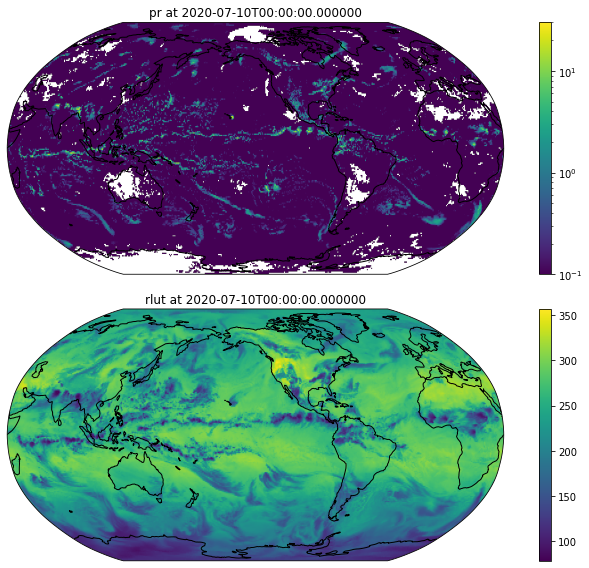

In [18]:
rlut_time = '2020-07-10T00:00'
pr_time = '2020-07-10T00:00'

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8), 
                                subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})

def egh_plot(data, ax, title=None, **kwargs):
    if title:
        ax.set_title(title)
    else:
        ax.set_title(data.name)
    ax.set_global()
    im = egh.healpix_show(data, ax=ax, **kwargs)
    plt.colorbar(im, ax=ax)
    ax.coastlines()

# Plot pr at :30
pr_data = ds.pr.sel(time=pr_time, method='nearest') * pr_scale
egh_plot(pr_data, ax=ax0, 
         title=f'pr at {pr_data.time.values}',
         norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30))

# Plot rlut at :00
rlut_data = ds.rlut.sel(time=rlut_time, method='nearest')
egh_plot(rlut_data, ax=ax1,
         title=f'rlut at {rlut_data.time.values}')

plt.tight_layout()
plt.show()

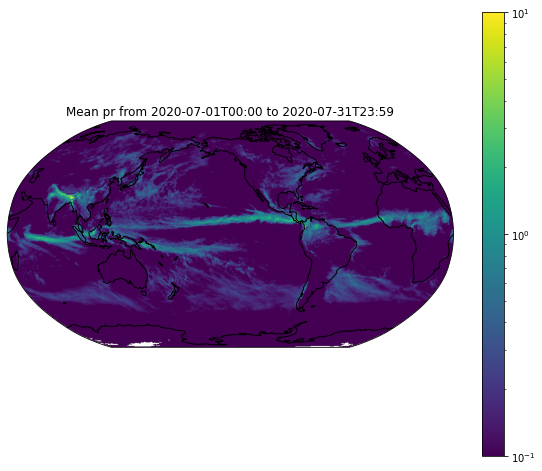

In [19]:
stime = '2020-07-01T00:00'
etime = '2020-07-31T23:59'
pr_avg = ds.pr.sel(time=slice(stime, etime)).mean(dim='time') * pr_scale

fig, ax0 = plt.subplots(1, 1, figsize=(10, 8), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})
egh_plot(pr_avg, ax=ax0, 
         title=f'Mean pr from {stime} to {etime}',
         norm=mpl.colors.LogNorm(vmin=10e-2, vmax=10))

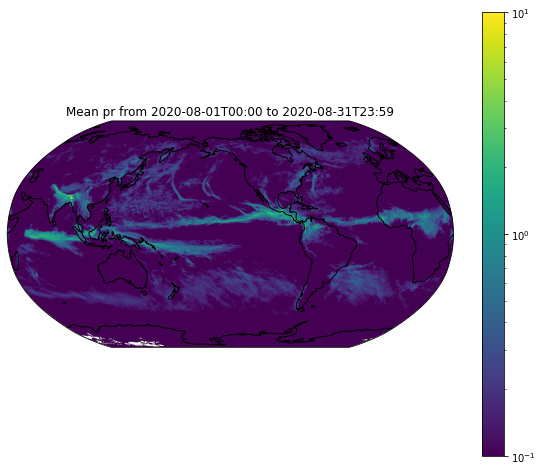

In [20]:
stime = '2020-08-01T00:00'
etime = '2020-08-31T23:59'
pr_avg = ds.pr.sel(time=slice(stime, etime)).mean(dim='time') * pr_scale

fig, ax0 = plt.subplots(1, 1, figsize=(10, 8), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})
egh_plot(pr_avg, ax=ax0, 
         title=f'Mean pr from {stime} to {etime}',
         norm=mpl.colors.LogNorm(vmin=10e-2, vmax=10))